# RFM Customer Analysis

RFM analysis segments customers using three measures:

- **Recency**: how recently a customer purchased.
- **Frequency**: how often a customer purchased, measured here by distinct qualifying invoices.
- **Monetary value**: how much a customer spent on qualifying sales.

This helps an ecommerce business identify loyal customers, high-value customers, new buyers, inactive customers, and customers at risk of churning. Customer IDs are required, so transactions without a usable `CustomerID` are excluded from customer-level RFM analysis. The reference date is the latest date in this historical dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")

clean_df = df.copy()
clean_df["InvoiceNo"] = clean_df["InvoiceNo"].astype(str).str.strip()
clean_df["StockCode"] = clean_df["StockCode"].astype(str).str.strip()
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"], errors="coerce")
clean_df["Quantity"] = pd.to_numeric(clean_df["Quantity"], errors="coerce")
clean_df["UnitPrice"] = pd.to_numeric(clean_df["UnitPrice"], errors="coerce")
clean_df = clean_df.drop_duplicates().copy()
clean_df["IsCancelled"] = clean_df["InvoiceNo"].str.startswith("C")
clean_df["IsReturned"] = clean_df["Quantity"] < 0

required_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]
clean_df = clean_df.dropna(subset=required_columns).copy()

non_product_codes = {
    "POST", "DOT", "M", "MANUAL", "D", "DISCOUNT",
    "AMAZONFEE", "BANK CHARGES", "CRUK", "S"
}
clean_df["StockCodeUpper"] = clean_df["StockCode"].str.upper()
clean_df = clean_df[
    (~clean_df["IsCancelled"]) &
    (~clean_df["IsReturned"]) &
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0) &
    (~clean_df["StockCodeUpper"].isin(non_product_codes))
].copy()
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print(f"Qualifying sales rows: {len(clean_df):,}")
print(f"Qualifying revenue: GBP {clean_df['Revenue'].sum():,.2f}")
print(f"Customers available for RFM: {clean_df['CustomerID'].nunique():,}")

Qualifying sales rows: 391,286
Qualifying revenue: GBP 8,743,913.64
Customers available for RFM: 4,334


In [2]:
reference_date = clean_df["InvoiceDate"].max().normalize()

customer_rfm = (
    clean_df.groupby("CustomerID", as_index=False)
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("Revenue", "sum"),
        ItemsPurchased=("Quantity", "sum"),
    )
)
customer_rfm["Recency"] = (
    reference_date - customer_rfm["LastPurchase"].dt.normalize()
).dt.days

customer_rfm = customer_rfm[
    [
        "CustomerID", "Recency", "Frequency", "MonetaryValue",
        "ItemsPurchased", "LastPurchase",
    ]
]

display(customer_rfm.head())
print(f"RFM reference date: {reference_date.date()}")
display(customer_rfm[["Recency", "Frequency", "MonetaryValue"]].describe().round(2))

,CustomerID,Recency,Frequency,MonetaryValue,ItemsPurchased,LastPurchase
0,12346.0,325,1,77183.60,74215,2011-01-18 10:01:00
1,12347.0,2,7,4310.00,2458,2011-12-07 15:52:00
2,12348.0,75,4,1437.24,2332,2011-09-25 13:13:00
3,12349.0,18,1,1457.55,630,2011-11-21 09:51:00
4,12350.0,310,1,294.40,196,2011-02-02 16:01:00


RFM reference date: 2011-12-09


,Recency,Frequency,MonetaryValue
count,4334.00,4334.00,4334.00
mean,92.23,4.25,2017.52
std,100.18,7.64,8920.36
min,0.00,1.00,3.75
25%,17.00,1.00,304.30
50%,50.00,2.00,663.71
75%,142.00,5.00,1631.62
max,373.00,206.00,279138.02


In [3]:
# Higher recency scores mean more recent purchases; higher frequency and monetary scores mean higher values.
customer_rfm["R_Score"] = pd.qcut(
    customer_rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1],
).astype(int)
customer_rfm["F_Score"] = pd.qcut(
    customer_rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)
customer_rfm["M_Score"] = pd.qcut(
    customer_rfm["MonetaryValue"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)
customer_rfm["RFM_Score"] = (
    customer_rfm["R_Score"].astype(str)
    + customer_rfm["F_Score"].astype(str)
    + customer_rfm["M_Score"].astype(str)
)

def assign_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    if row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"
    if row["M_Score"] >= 4 and row["F_Score"] <= 3:
        return "Big Spenders"
    if row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "New Customers"
    if row["R_Score"] <= 2 and row["M_Score"] >= 3:
        return "At Risk"
    if row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"
    return "Developing Customers"

customer_rfm["Segment"] = customer_rfm.apply(assign_segment, axis=1)
display(customer_rfm.head(10))

,CustomerID,Recency,Frequency,MonetaryValue,ItemsPurchased,LastPurchase,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,325,1,77183.60,74215,2011-01-18 10:01:00,1,1,5,115,Big Spenders
1,12347.0,2,7,4310.00,2458,2011-12-07 15:52:00,5,5,5,555,Champions
2,12348.0,75,4,1437.24,2332,2011-09-25 13:13:00,2,4,4,244,At Risk
3,12349.0,18,1,1457.55,630,2011-11-21 09:51:00,4,1,4,414,Big Spenders
4,12350.0,310,1,294.40,196,2011-02-02 16:01:00,1,1,2,112,Lost Customers
5,12352.0,36,7,1385.74,526,2011-11-03 14:37:00,3,5,4,354,Loyal Customers
6,12353.0,204,1,89.00,20,2011-05-19 17:47:00,1,1,1,111,Lost Customers
7,12354.0,232,1,1079.40,530,2011-04-21 13:11:00,1,1,4,114,Big Spenders
8,12355.0,214,1,459.40,240,2011-05-09 13:49:00,1,1,2,112,Lost Customers
9,12356.0,22,3,2487.43,1573,2011-11-17 08:40:00,4,3,5,435,Big Spenders


In [4]:
segment_summary = (
    customer_rfm.groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        Revenue=("MonetaryValue", "sum"),
        AverageCustomerValue=("MonetaryValue", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageRecency=("Recency", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)
segment_summary["RevenueSharePct"] = (
    segment_summary["Revenue"] / segment_summary["Revenue"].sum() * 100
)

print("RFM SEGMENT SUMMARY")
display(
    segment_summary.round(
        {"Revenue": 2, "AverageCustomerValue": 2, "AverageFrequency": 2, "AverageRecency": 2, "RevenueSharePct": 2}
    )
)

RFM SEGMENT SUMMARY


,Segment,Customers,Revenue,AverageCustomerValue,AverageFrequency,AverageRecency,RevenueSharePct
2,Champions,941,5665283.61,6020.49,11.14,11.99,64.79
1,Big Spenders,371,901340.48,2429.49,2.14,93.35,10.31
5,Loyal Customers,505,893872.77,1770.05,5.09,36.54,10.22
0,At Risk,543,671651.89,1236.93,3.22,150.87,7.68
3,Developing Customers,864,337229.71,390.31,1.87,69.67,3.86
4,Lost Customers,830,187984.50,226.49,1.04,226.77,2.15
6,New Customers,280,86550.68,309.11,1.19,17.90,0.99


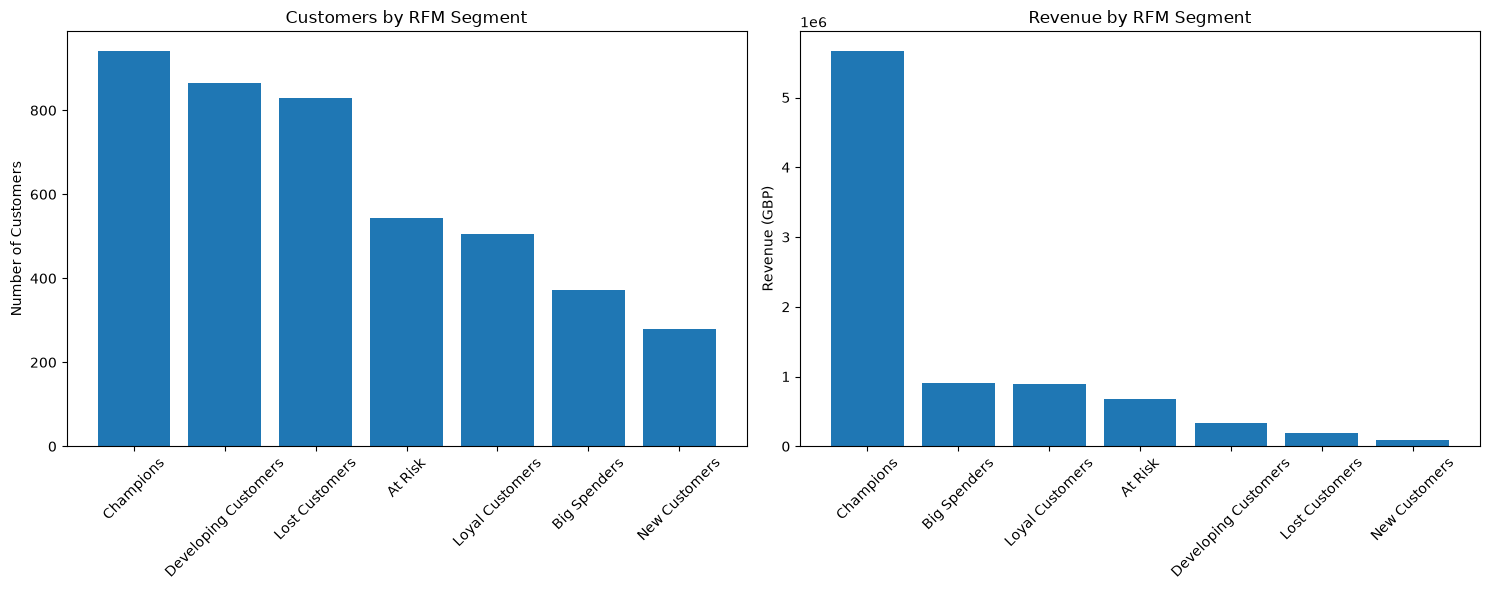

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

segment_counts = segment_summary.sort_values("Customers", ascending=False)
axes[0].bar(segment_counts["Segment"], segment_counts["Customers"])
axes[0].set_title("Customers by RFM Segment")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=45)

segment_revenue = segment_summary.sort_values("Revenue", ascending=False)
axes[1].bar(segment_revenue["Segment"], segment_revenue["Revenue"])
axes[1].set_title("Revenue by RFM Segment")
axes[1].set_ylabel("Revenue (GBP)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()